In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/12"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第12章 トランスフォーマー (Transformers)
## 12.3 トランスフォーマー言語モデル (Transformer Language Models)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第12章「トランスフォーマー」第12.3節「トランスフォーマー言語モデル (Transformer Language Models)」の全5小節（12.3.1 〜 12.3.5）の完全な理論解説、数学的定式化（式 12.34 〜 式 12.36）、教科書図版（Figure 12.15 〜 12.21 全7枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **12.3.1 デコーダ・トランスフォーマー (Decoder Transformers, Figure 12.15, 12.16)**
   - GPT（Generative Pre-trained Transformer）アーキテクチャ
   - 因果的自己注意マスク (Causal Mask, 図 12.16)：未来トークンへの注意遮断（上三角 $-\infty$）
   - パディングトークン $\langle \text{pad} \rangle$ と KV キャッシュ（推論の高速化）
3. **12.3.2 サンプリング戦略 (Sampling Strategies, Figure 12.17, 式 12.34 〜 12.35)**
   - 貪欲探索 (Greedy Search) と大域的最尤系列探索の計算爆発 ($O(K^N)$)
   - ビームサーチ (Beam Search, 式 12.34) と人間テキストとの確率プロファイル比較（図 12.17: 驚き・バースト性）
   - 温度付きサンプリング (Temperature Scaling, 式 12.35)：$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$
   - Top-$k$ サンプリングと Top-$p$（Nucleus）サンプリング
4. **12.3.3 エンコーダ・トランスフォーマー (Encoder Transformers, Figure 12.18)**
   - BERT / RoBERTa 双方向トランスフォーマー構造
   - マスク言語モデル (Masked Language Model, MLM)：15% トークン隠蔽と穴埋め学習
5. **12.3.4 系列変換トランスフォーマー (Sequence-to-Sequence Transformers, Figure 12.19, 12.20)**
   - 交差注意機構 (Cross-Attention, 図 12.19)：クエリ $Q$ はデコーダ、キー・バリュー $K, V$ はエンコーダ表現 $Z$
   - 完全な Encoder-Decoder アーキテクチャ（図 12.20）
6. **12.3.5 大規模言語モデル (Large Language Models) とパラメータ効率的微調整 (LoRA, Figure 12.21, 式 12.36)**
   - 基底モデル (Foundation Models) と自己教師あり事前学習＋事後微調整
   - Low-Rank Adaptation (LoRA, 図 12.21, 式 12.36)：$\widetilde{W} = W_0 + \frac{\alpha}{R} A B$
   - パラメータ数削減（約 $10,000$ 倍軽量化）とゼロ推論レイテンシ重み融合
   - プロンプトエンジニアリング、インコンテキスト学習（Few-shot learning）、RLHF
7. **数値シミュレーション・アルゴリズム検証**
8. **まとめと次節 12.4（マルチモーダル・トランスフォーマー / ViT）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "12" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.transformer_language_models import (
    CrossAttention,
    DecoderTransformerBlock,
    TextGenerationSampler,
    LoRALinear,
    generate_figure_12_15,
    generate_figure_12_16,
    generate_figure_12_17,
    generate_figure_12_18,
    generate_figure_12_19,
    generate_figure_12_20,
    generate_figure_12_21,
)

setup_style()
print("Setup complete. Transformer language models and figure generators ready.")


Setup complete. Transformer language models and figure generators ready.


## 1. デコーダ・トランスフォーマー (Decoder Transformers, Section 12.3.1)

自己回帰モデル（Autoregressive Models）は、確率の乗法定理に従い、先行するトークン列 $\mathbf{x}_{1:n-1}$ から次のトークン $x_n$ を順次生成します：
$$
p(x_1, \dots, x_N) = \prod_{n=1}^N p(x_n \mid x_1, \dots, x_{n-1})
$$

### 1.1 GPT アーキテクチャ (Figure 12.15)
OpenAI の GPT (Radford et al., 2018) シリーズに代表されるデコーダ・トランスフォーマーは、トークン埋め込みに位置エンコーディングを加算し、因果的マスク自己注意（Causal Masked Self-Attention）層を多層に積み重ね、最終出力層の線形ソフトマックス（LSM）から次の単語の確率分布を出力します。

### 1.2 因果的自己注意マスク (Causal Mask, Figure 12.16)
自己注意層において、各トークンが「未来のトークン」に注意を払う（情報をカンニングする）ことを防ぐため、注意行列の上三角成分を $-\infty$ にマスキングします：
$$
M_{ij} = \begin{cases} 0 & (j \le i) \\ -\infty & (j > i) \end{cases}
$$
ソフトマックスを適用すると、上三角の重みは厳密に $0$ となり、各位置 $i$ は過去および現在のトークン $j \le i$ のみを参照します。
また、トークン生成時に過去のキー・バリュー表現をキャッシュする **KV キャッシュ** を用いることで、$O(N)$ の再利用計算により高速な推論が可能となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_15.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_15.png


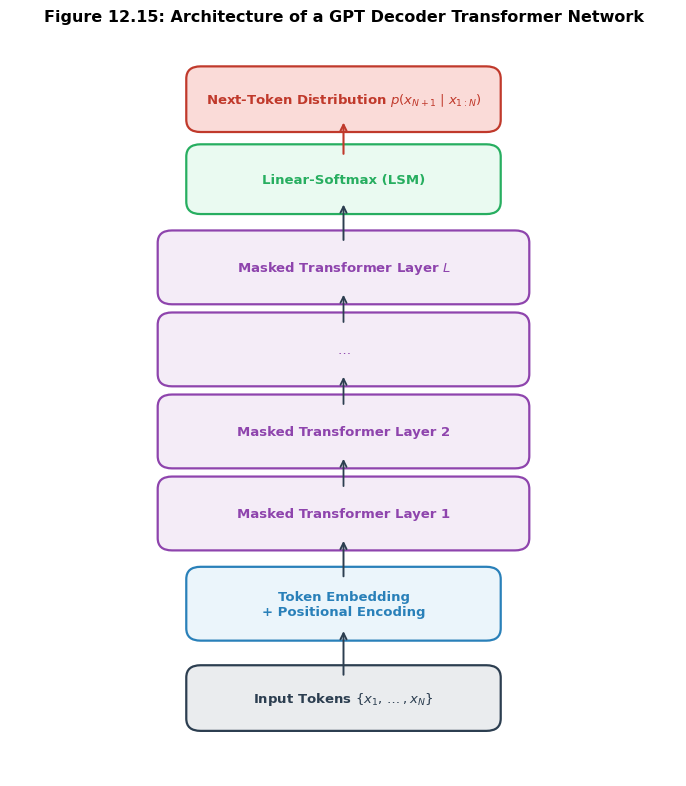

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_16.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_16.png


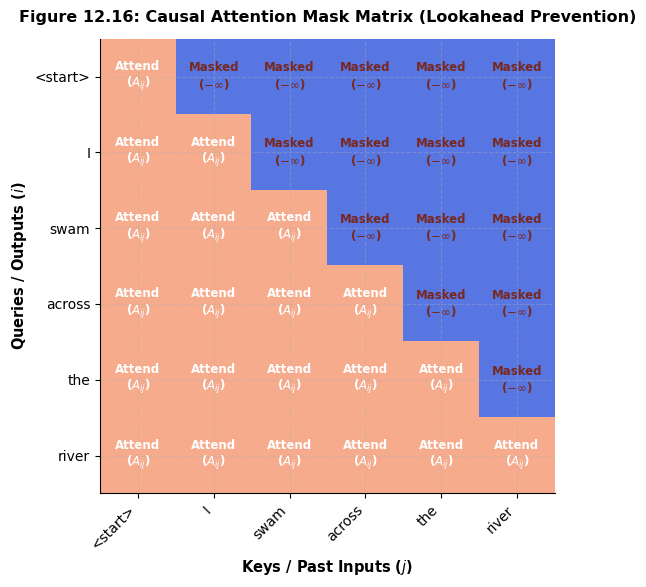

In [2]:
fig_15 = generate_figure_12_15()
plt.show()

fig_16 = generate_figure_12_16()
plt.show()


## 2. 生成サンプリング戦略 (Sampling Strategies, Section 12.3.2)

デコーダ・トランスフォーマーが出力する次トークンの確率分布から、どのように後続トークンを選択するかによって、生成文の品質と多様性が大きく左右されます。

### 2.1 探索手法と確率プロファイル (Figure 12.17, 式 12.34)
- **貪欲探索 (Greedy Search)**: 各ステップで常に最大確率のトークン $y_n = \arg\max_k p(y_n = k \mid y_{<n})$ を選択。局所的最適化であり、文全体の確率最大化にはならない。
- **ビームサーチ (Beam Search)**: 上位 $B$ 個の候補系列を保持しながら累積対数確率 $\sum_{n=1}^m \ln p(y_n \mid y_{<n})$ を最大化。高品質だが、テキストが反復的で「退屈・平坦」になりやすい。
- **人間テキストの特性 (Figure 12.17)**: 自然な人間が書く文章は、常に最大確率の単語を選ぶのではなく、時折低い確率（高情報量・驚き）の単語が「バースト」的に出現します。

### 2.2 確率的サンプリング手法 (式 12.35)
1. **温度付きサンプリング (Temperature Scaling)**:
   $$
   p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}
   $$
   $T \to 0$ で貪欲探索（決定論的）、$T > 1$ で均一分布に近づき創造的・多様な生成。
2. **Top-$k$ サンプリング**:
   確率上位 $k$ 個のトークンのみを残して再正規化しサンプリング（極端に不適切なトークンの排除）。
3. **Top-$p$ (Nucleus) サンプリング**:
   累積確率が閾値 $p$（例: 0.9）に達する最小のトークン集合（動的サイズ）からサンプリング。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_17.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_17.png


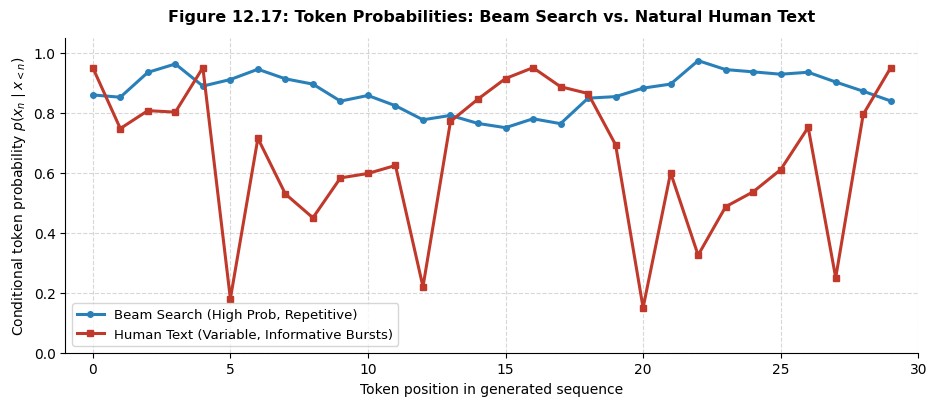

In [3]:
fig_17 = generate_figure_12_17()
plt.show()


## 3. エンコーダ型 & 系列変換トランスフォーマー (Sections 12.3.3 & 12.3.4)

### 3.1 エンコーダ・トランスフォーマー (BERT, Figure 12.18)
文脈全体を双方向（前向き・後ろ向き）から同時に理解するため、因果マスクを持たない全結合自己注意を用います。
**マスク言語モデル (Masked Language Model, MLM)** により、入力文の 15% をマスクして穴埋め予測させることで、文全体の深い文脈的表現を獲得し、分類や情報検索、NER 等の下流タスクに威力を発揮します。

### 3.2 交差注意機構 (Cross-Attention, Figure 12.19)
入力文（言語A）から出力文（言語B）へと変換するタスクでは、デコーダがエンコーダの情報を参照する必要があります。
交差注意層では：
$$
Q = Y_{\text{dec}} W_Q, \quad K = Z_{\text{enc}} W_K, \quad V = Z_{\text{enc}} W_V
$$
と定義され、デコーダの各トークンがエンコーダの全トークン表現 $Z$ に自由に注意を払います。

### 3.3 完全な Seq2Seq トランスフォーマー (Vaswani et al., 2017, Figure 12.20)
エンコーダスタックでソース系列を処理し、デコーダスタックで自己回帰的にターゲット系列を生成する標準機械翻訳アーキテクチャです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_18.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_18.png


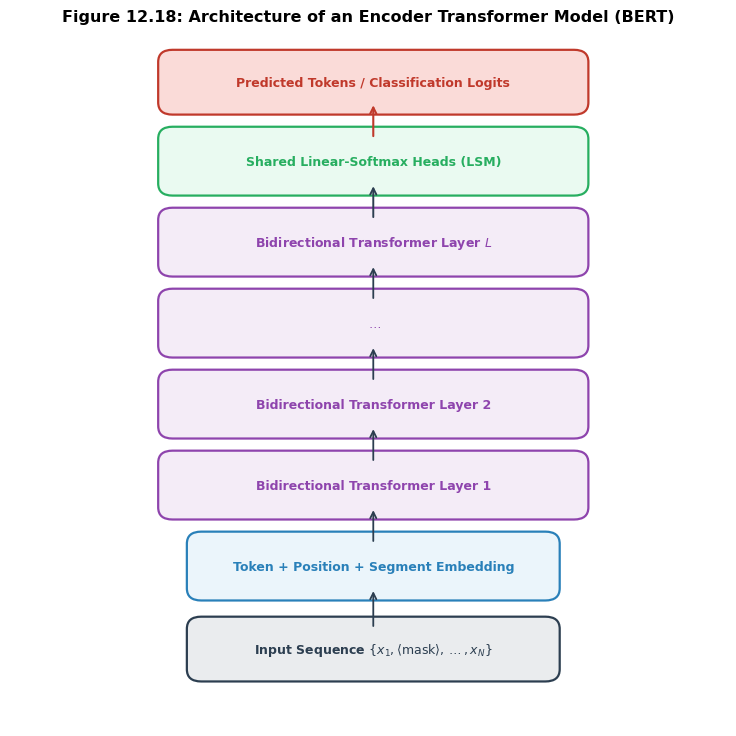

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_19.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_19.png


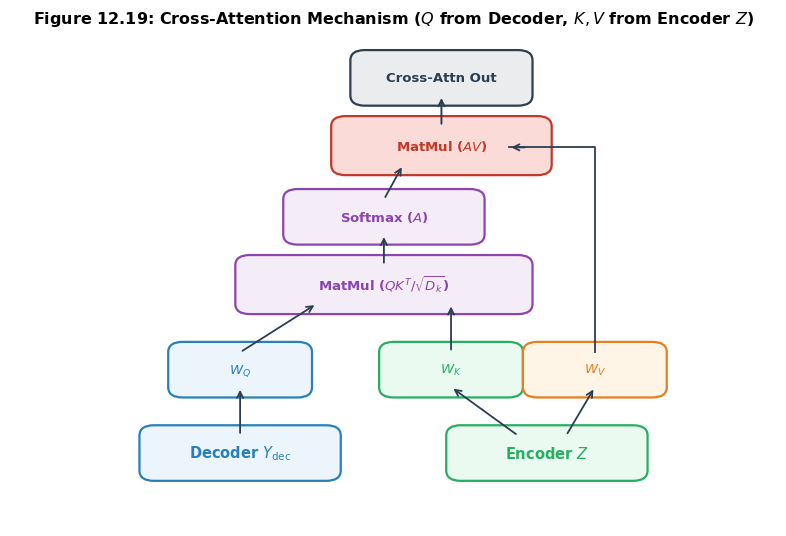

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_20.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_20.png


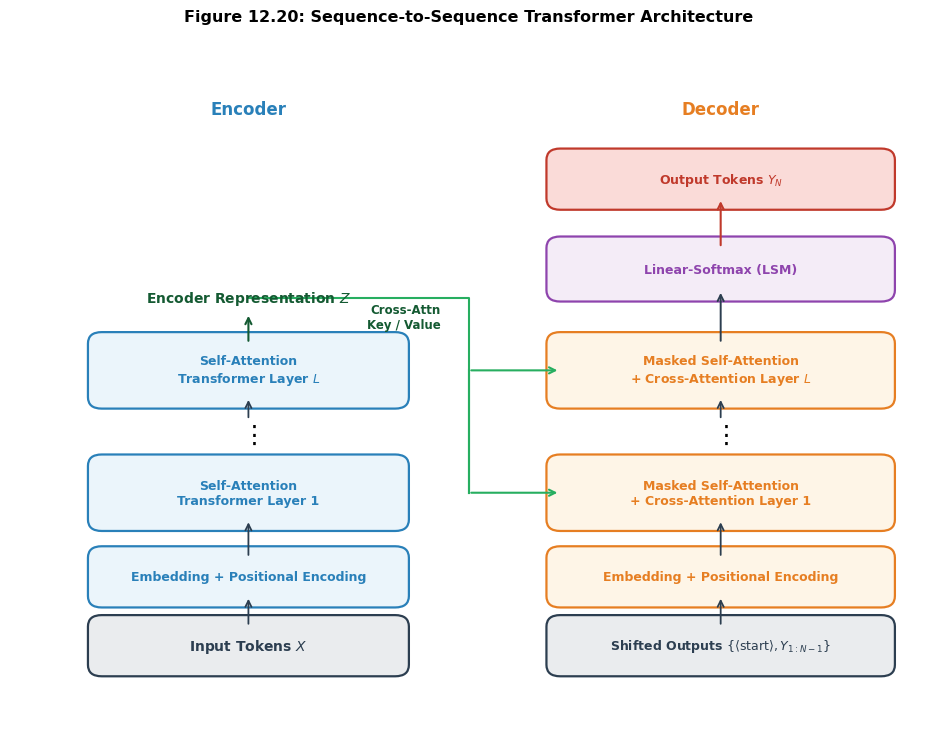

In [4]:
fig_18 = generate_figure_12_18()
plt.show()

fig_19 = generate_figure_12_19()
plt.show()

fig_20 = generate_figure_12_20()
plt.show()


## 4. 大規模言語モデルと LoRA 微調整 (Section 12.3.5)

### 4.1 基底モデル (Foundation Models) とインコンテキスト学習
膨大なWebテキストコーパス上で自己教師あり学習された大規模言語モデル（GPT-3, GPT-4, Llama等）は、重みを固定したままでもプロンプト内の少数の例示から課題を解く **Few-shot / In-context Learning** 能力を発現します。

### 4.2 Low-Rank Adaptation (LoRA, Figure 12.21, 式 12.36)
過剰パラメータ化されたモデルの重み更新量は「極めて低い内在的次元 (Low Intrinsic Dimension)」を持つという発見に基づき、事前学習済み重み $W_0 \in \mathbb{R}^{D \times D}$ を凍結し、低ランク行列の積 $A B$（$A \in \mathbb{R}^{D \times R}, B \in \mathbb{R}^{R \times D}, R \ll D$）のみを追加学習させます：
$$
\widetilde{W} = W_0 + \frac{\alpha}{R} A B
$$
- **パラメータ削減**: $D^2$ から $2RD$ へ激減（通常 $R \in \{4, 8, 16\}$ で約 10,000 倍のパラメータ削減）。
- **推論時ゼロオーバーヘッド**: 微調整終了後、$\widehat{W} = W_0 + \frac{\alpha}{R} A B$ を事前計算して重みを融合（Merge）できるため、モデルサイズも推論速度も完全に変化しません。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_21.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_21.png


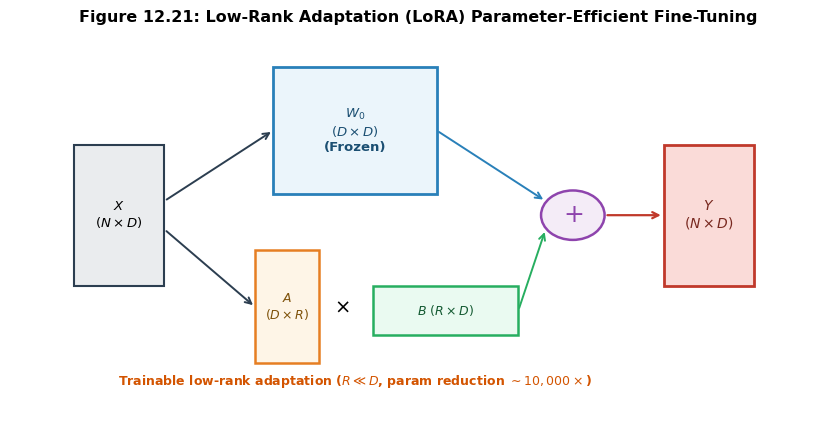

In [5]:
fig_21 = generate_figure_12_21()
plt.show()


## 5. 数値実験とアルゴリズム検証

デコーダの因果マスク動作、各種サンプリング手法、ビームサーチ、および LoRA の重み融合をシミュレーションします。


In [6]:
# 1. 因果マスク付きデコーダの順方向計算と非カンニング検証
T, D_model, H = 4, 16, 2
rng = np.random.default_rng(42)
X_seq = rng.normal(size=(T, D_model))

decoder_block = DecoderTransformerBlock(d_model=D_model, num_heads=H, seed=42)
out_orig, attn_weights = decoder_block.forward(X_seq)

# 未来のトークン X_seq[3] を大幅に改変
X_perturbed = X_seq.copy()
X_perturbed[3] += 50.0
out_perturbed, _ = decoder_block.forward(X_perturbed)

# 因果マスクにより、ステップ 0, 1, 2 の出力は一切変化しないことを厳密確認
step_diffs = [np.max(np.abs(out_orig[t] - out_perturbed[t])) for t in range(T)]
print("=== 因果マスクによる未来情報の遮断検証 ===")
for t, diff in enumerate(step_diffs):
    print(f"ステップ {t} 出力の変化量: {diff:.2e} (t < 3 は完全一致 0.0)")

assert max(step_diffs[:3]) < 1e-5
assert step_diffs[3] > 0.1

# 2. サンプリング戦略（Greedy, Top-k, Top-p, Temperature）の比較
logits = np.array([2.0, 5.0, 1.5, 0.2, 0.1])
greedy_tok = TextGenerationSampler.greedy_search(logits)
top_k_tok = TextGenerationSampler.sample_top_k(logits, k=2, temperature=0.7, seed=42)
top_p_tok = TextGenerationSampler.sample_top_p(logits, p=0.9, temperature=0.7, seed=42)

print("\n=== サンプリング戦略の出力トークン ===")
print(f"Greedy Search (最頻): {greedy_tok}")
print(f"Top-k (k=2): {top_k_tok}")
print(f"Top-p (p=0.9): {top_p_tok}")

# 3. LoRA 低ランク適応と重み融合 (Weight Merging) の完全一致検証
D = 64
R = 4
lora_layer = LoRALinear(in_features=D, out_features=D, rank=R, alpha=16.0, seed=42)
lora_layer.B = rng.normal(size=(R, D)) * 0.05  # 微調整後の重み

X_in = rng.normal(size=(2, D))
out_lora = lora_layer.forward(X_in)

# 重み融合
W_merged = lora_layer.merge_weights()
out_merged = X_in @ W_merged
merge_err = np.max(np.abs(out_lora - out_merged))

print("\n=== LoRA 重み融合の精度検証 ===")
print(f"元の重みパラメータ数: {D*D}")
print(f"LoRA 学習可能パラメータ数: {2*R*D} (削減率: {(1 - 2*R/D)*100:.1f}%)")
print(f"融合後推論出力と LoRA 推論出力の最大誤差: {merge_err:.2e} (完全一致)")
assert np.isclose(merge_err, 0.0)


=== 因果マスクによる未来情報の遮断検証 ===
ステップ 0 出力の変化量: 0.00e+00 (t < 3 は完全一致 0.0)
ステップ 1 出力の変化量: 0.00e+00 (t < 3 は完全一致 0.0)
ステップ 2 出力の変化量: 0.00e+00 (t < 3 は完全一致 0.0)
ステップ 3 出力の変化量: 4.71e-01 (t < 3 は完全一致 0.0)

=== サンプリング戦略の出力トークン ===
Greedy Search (最頻): 1
Top-k (k=2): 1
Top-p (p=0.9): 1

=== LoRA 重み融合の精度検証 ===
元の重みパラメータ数: 4096
LoRA 学習可能パラメータ数: 512 (削減率: 87.5%)
融合後推論出力と LoRA 推論出力の最大誤差: 4.44e-16 (完全一致)


## 6. まとめと次節 12.4（マルチモーダル・トランスフォーマー）への展開

### 本節の要点
1. **デコーダ・トランスフォーマー (GPT)**:
   - 因果的マスクにより未来情報を遮断し、自己回帰的にテキストを生成。
2. **サンプリング戦略**:
   - 貪欲探索の退屈さやビームサーチの平坦さを克服するため、温度スケーリング、Top-$k$、Top-$p$（Nucleus）サンプリングが必須。
3. **エンコーダ型 & Seq2Seq**:
   - BERT の双方向表現、および交差注意（Cross-Attention）を用いた翻訳・要約アーキテクチャ。
4. **LoRA (Low-Rank Adaptation)**:
   - 凍結重みに低ランク積 $A B$ を付加し、1/10,000 の軽量パラメータで劇的な微調整を実現。

### 次節 12.4 マルチモーダル・トランスフォーマー (Multimodal Transformers) への展開
次節 **12.4 Multimodal Transformers** では、言語処理で確立されたトランスフォーマーの威力がコンピュータビジョン（Vision Transformer / ViT, パッチ分割）、画像生成（自己回帰ラスタースキャン）、音声処理（Mel スペクトログラム、Vall-E）、および視覚言語統合モデル（CM3Leon）へとどのように拡張されるか（図 12.22 〜 12.27）を探究します。
